# TB-DOTS CAR CDSS — LightGBM Treatment Outcome Prediction

This notebook trains a **LightGBM** classifier for predicting TB treatment outcome (**Success / Failure**) using monthly patient monitoring data and baseline clinical features.

### Class Imbalance Handling
To address the severe class imbalance (~90% Success / ~10% Failure):
- **SMOTE-ENN** (Synthetic Minority Oversampling + Edited Nearest Neighbors) — generates synthetic Failure samples then removes noisy/misclassified samples via ENN cleaning
- **`is_unbalance=True`** — LightGBM's native class reweighting
- **Threshold optimization** — finds optimal classification threshold on validation set

### Progressive Temporal Prediction
Each model supports **prediction at any month** (M0–M12). For each month `t`, features include:
- **Static features** (51 baseline clinical features)
- **Temporal features up to month t** (flattened + aggregates + trends)

### Outputs
- Trained model checkpoint → `models/Temporal/output/lightgbm/lgb_smoteenn_model.txt`
- Evaluation report → `models/Temporal/output/lightgbm/lgb_evaluation_report.txt`
- Feature importance → `models/Temporal/output/lightgbm/lgb_feature_importance.png`
- Per-month performance → `models/Temporal/output/lightgbm/lgb_per_month_performance.png`
- Validation curve → `models/Temporal/output/lightgbm/lgb_training_curve.png`
- Metrics/config files → `models/Temporal/output/lightgbm/`


## 0. Imports & Configuration

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Paths ───────────────────────────────────────────────────────
REPO_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "dataset").exists() and (p / "models").exists()),
    Path.cwd(),
)
BASE_DIR = REPO_ROOT
DATA_DIR = REPO_ROOT / "dataset" / "temporal"
MODEL_DIR = REPO_ROOT / "models" / "Temporal" / "v2" / "output" / "lightgbm"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"LightGBM: {lgb.__version__}")
print(f"Data    : {DATA_DIR}")
print(f"Models  : {MODEL_DIR}")


LightGBM: 4.6.0
Data    : c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\dataset\temporal
Models  : c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\lightgbm


## 1. Data Loading & Label Creation

Load the same preprocessed temporal and static arrays. Outcome columns are removed from static features to prevent target leakage. Binary labels:
- **Success (1)** = Cured, Treatment Completed
- **Failure (0)** = Died, Lost to Follow-Up, Not Evaluated

In [2]:
def load_data():
    """Load harmonized temporal data with trustworthy train-fit transforms."""
    import sys
    sys.path.append(str(BASE_DIR / "models" / "Temporal"))
    import model_utils as mu

    csv_path = DATA_DIR / "combined_complete_dataset.csv"
    model_data = mu.prepare_default_model_inputs(
        str(csv_path),
        train_frac=0.70,
        val_frac=0.20,
        test_frac=0.10,
        random_state=SEED,
        drop_feature_cols={"data_year", "source_file"},
    )

    X_temporal = model_data["X_temporal"]
    X_static = model_data["X_static"]
    y = model_data["y"]
    static_names = list(model_data["static_feature_names"])
    temporal_names = list(model_data["temporal_feature_names"])
    train_idx = model_data["train_idx"]
    val_idx = model_data["val_idx"]
    test_idx = model_data["test_idx"]
    df = model_data["df"]

    print(f"Temporal features : {X_temporal.shape}")
    print(f"Static features   : {X_static.shape}  (all columns kept except data_year/source_file)")
    print(f"Labels            : {y.shape}  (Success={int(y.sum())}, Failure={int(len(y) - y.sum())})")
    print(f"Split sizes       : train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

    return X_temporal, X_static, y, static_names, temporal_names, df, train_idx, val_idx, test_idx


X_temporal, X_static, y, static_names, temporal_names, df, train_idx, val_idx, test_idx = load_data()


STAGE 3: Data Cleaning & Type Coercion
  Parsed 'date_of_birth': 573/599 valid, 26 filled with median (1975-10-23)
  Parsed 'date_of_diagnosis': 477/599 valid, 122 filled with median (2023-08-29)
  Parsed 'date_of_notification': 432/599 valid, 167 filled with median (2023-09-23)
  Parsed 'treatment_start_date': 541/599 valid, 58 filled with median (2023-08-19)
  Parsed 'date_of_outcome': 355/599 valid, 244 filled with median (2023-12-03)
  Parsed 'intensive_phase_start_date': 461/599 valid, 138 filled with median (2023-10-11)
  Parsed 'intensive_phase_end_date': 381/599 valid, 218 filled with median (2023-12-08)
  Parsed 'continuation_phase_start_date': 359/599 valid, 240 filled with median (2023-12-09)
  Parsed 'continuation_phase_end_date': 367/599 valid, 232 filled with median (2024-03-21)
  Fixed 1 future DOBs by subtracting 100 years
  Fixed 2 historically implausible DOBs (pre-1920) by adding 100 years
  Fixed 29 future dates in 'date_of_diagnosis' by subtracting 10 years
  Fixed

## 2. Feature Engineering

Transform 3D temporal data into flat 2D features for LightGBM. Same feature engineering as the other tree-based models for fair comparison.

In [3]:
def build_features_at_month(X_temporal, X_static, up_to_month, temporal_names, static_names):
    """
    Build a flat feature matrix using data up to `up_to_month`.

    Features include:
    1. Static baseline features (always the same)
    2. Flattened raw temporal features up to month t
    3. Aggregate stats (mean, std, min, max) over available months
    4. Trend (linear slope) of key features
    5. Latest month's values
    6. Month indicator (how much data is available)

    Returns: X_flat (n_patients, n_features), feature_name_list
    """
    n_patients = X_temporal.shape[0]
    n_temporal_feats = X_temporal.shape[2]  # 8
    valid_months = up_to_month + 1

    feature_list = []
    feature_name_list = []

    # 1. Static features (always included)
    feature_list.append(X_static)
    feature_name_list.extend(static_names)

    # 2. Flattened temporal features for months 0..up_to_month
    temporal_flat = X_temporal[:, :valid_months, :].reshape(n_patients, -1)
    for m in range(valid_months):
        for feat in temporal_names:
            feature_name_list.append(f"M{m}_{feat}")
    feature_list.append(temporal_flat)

    # 3. Aggregate statistics over available months
    temporal_slice = X_temporal[:, :valid_months, :]  # (N, valid_months, 8)
    for agg_name, agg_fn in [("mean", np.mean), ("std", np.std),
                              ("min", np.min), ("max", np.max)]:
        agg = agg_fn(temporal_slice, axis=1)  # (N, 8)
        feature_list.append(agg)
        for feat in temporal_names:
            feature_name_list.append(f"{agg_name}_{feat}")

    # 4. Trend features (linear slope) for key temporal features
    if valid_months >= 2:
        slopes = np.zeros((n_patients, n_temporal_feats))
        x_time = np.arange(valid_months, dtype=np.float32)
        for i in range(n_patients):
            for j in range(n_temporal_feats):
                vals = temporal_slice[i, :, j]
                if np.std(vals) > 1e-8:
                    slope = np.polyfit(x_time, vals, 1)[0]
                else:
                    slope = 0.0
                slopes[i, j] = slope
        feature_list.append(slopes)
        for feat in temporal_names:
            feature_name_list.append(f"trend_{feat}")
    else:
        feature_list.append(np.zeros((n_patients, n_temporal_feats)))
        for feat in temporal_names:
            feature_name_list.append(f"trend_{feat}")

    # 5. Latest month's values
    latest = X_temporal[:, up_to_month, :]  # (N, 8)
    feature_list.append(latest)
    for feat in temporal_names:
        feature_name_list.append(f"latest_{feat}")

    # 6. Month indicator
    month_indicator = np.full((n_patients, 1), up_to_month, dtype=np.float32)
    feature_list.append(month_indicator)
    feature_name_list.append("months_available")

    X_flat = np.hstack(feature_list).astype(np.float32)
    X_flat = np.nan_to_num(X_flat, nan=0.0)

    return X_flat, feature_name_list


# Demo: build features at M12 (full data) to check dimensions
X_full, feat_names_full = build_features_at_month(
    X_temporal, X_static, up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)
print(f"Full feature matrix (M12): {X_full.shape}")
print(f"Number of features: {len(feat_names_full)}")

Full feature matrix (M12): (431, 723)
Number of features: 723


## 3. Patient-Level Train/Val/Test Split

Same 70/20/10 patient-level split as the other models (same random seed) for fair comparison.

In [4]:
print("Patient split (precomputed, patient-level stratified):")
for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    yi = y[idx]
    print(f"  {name:>5s}: {len(idx)} patients  (Success={int(yi.sum())}, Failure={int(len(yi) - yi.sum())})")


Patient split (precomputed, patient-level stratified):
  Train: 301 patients  (Success=257, Failure=44)
    Val: 86 patients  (Success=73, Failure=13)
   Test: 44 patients  (Success=38, Failure=6)


## 4. LightGBM Training with SMOTE-ENN

Train LightGBM with **progressive temporal data** and **SMOTE-ENN** augmentation.

### SMOTE-ENN Pipeline
1. **SMOTE** — generates synthetic minority (Failure) samples in feature space
2. **Edited Nearest Neighbors (ENN)** — removes noisy/borderline samples whose class label disagrees with the majority of their k-nearest neighbors

### Hyperparameters
- `n_estimators=300`, `max_depth=4`, `num_leaves=31`
- `is_unbalance=True` — LightGBM's native class reweighting
- Early stopping on validation loss

In [5]:
import sys
sys.path.append(str(BASE_DIR / "dataset" / "temporal"))
import model_utils as mu

scaled = mu.scale_full_arrays(X_static, X_temporal, train_idx)
X_static = scaled["X_static_scaled"]
X_temporal = scaled["X_temporal_scaled"]
mu.save_scalers(scaled["scaler_static"], scaled["scaler_temporal"], str(DATA_DIR))

print(f"Scaled arrays: X_temporal={X_temporal.shape}, X_static={X_static.shape}")
print(f"Split sizes: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

Scaled arrays: X_temporal=(431, 13, 8), X_static=(431, 570)
Split sizes: train=301, val=86, test=44


In [6]:
def train_lightgbm(X_temporal, X_static, y, train_idx, val_idx,
                   temporal_names, static_names,
                   save_name="lgb_smoteenn_model.txt"):
    """
    Train LightGBM with progressive temporal data and SMOTE-ENN.
    """
    X_train_full, feat_names = build_features_at_month(
        X_temporal[train_idx], X_static[train_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
    )

    X_val_full, _ = build_features_at_month(
        X_temporal[val_idx], X_static[val_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    y_val = y[val_idx]

    # Progressive training data (M0–M12 for each patient)
    X_train_prog = []
    y_train_prog = []
    for month in range(13):
        X_m, _ = build_features_at_month(
            X_temporal[train_idx], X_static[train_idx],
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
        )
        if X_m.shape[1] < X_train_full.shape[1]:
            pad_width = X_train_full.shape[1] - X_m.shape[1]
            X_m = np.hstack([X_m, np.zeros((X_m.shape[0], pad_width), dtype=np.float32)])
        X_train_prog.append(X_m)
        y_train_prog.append(y[train_idx])

    X_train_all = np.vstack(X_train_prog)
    y_train_all = np.concatenate(y_train_prog)

    print(f"\n{'='*55}")
    print(f"  LightGBM + SMOTE-ENN")
    print(f"{'='*55}")
    print(f"Progressive training samples: {X_train_all.shape[0]} "
          f"({len(train_idx)} patients × 13 months)")
    print(f"Feature dimensions: {X_train_all.shape[1]}")

    # ── Apply SMOTE-ENN ─────────────────────────────────────────
    n_minority = int((y_train_all == 0).sum())
    n_majority = int((y_train_all == 1).sum())
    print(f"\nBefore SMOTE-ENN: Success={n_majority}, Failure={n_minority}")

    k = min(5, n_minority - 1)
    if k >= 1:
        smote_enn = SMOTEENN(
            smote=SMOTE(random_state=SEED, k_neighbors=k),
            random_state=SEED,
        )
        X_train_all, y_train_all = smote_enn.fit_resample(X_train_all, y_train_all)

        n_minority_after = int((y_train_all == 0).sum())
        n_majority_after = int((y_train_all == 1).sum())
        print(f"After SMOTE-ENN:  Success={n_majority_after}, Failure={n_minority_after}")
        print(f"Total training samples: {len(y_train_all)} "
              f"(ENN removed noisy samples after SMOTE oversampling)")
    else:
        print(f"SMOTE-ENN skipped: not enough minority samples (k_neighbors={k})")

    # ── Train LightGBM ──────────────────────────────────────────
    model = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        is_unbalance=True,
        random_state=SEED,
        verbosity=-1,
        n_jobs=-1,
    )

    model.fit(
        X_train_all, y_train_all,
        eval_set=[(X_val_full, y_val)],
        eval_metric="logloss",
        callbacks=[
            lgb.early_stopping(stopping_rounds=20, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    # Save model
    model.booster_.save_model(str(MODEL_DIR / save_name))
    print(f"\nBest iteration: {model.best_iteration_}")
    print(f"Model saved to models/{save_name}")

    # Training history
    history = {
        "val_loss": list(model.evals_result_["valid_0"]["binary_logloss"]),
    }

    return model, history, feat_names


# ── Train ────────────────────────────────────────────────────────
lgb_model, lgb_history, feature_names_lgb = train_lightgbm(
    X_temporal, X_static, y, train_idx, val_idx,
    temporal_names, static_names,
    save_name="lgb_smoteenn_model.txt",
)


  LightGBM + SMOTE-ENN
Progressive training samples: 3913 (301 patients × 13 months)
Feature dimensions: 723

Before SMOTE-ENN: Success=3341, Failure=572


  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Ven\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                    

After SMOTE-ENN:  Success=3341, Failure=3341
Total training samples: 6682 (ENN removed noisy samples after SMOTE oversampling)

Best iteration: 79
Model saved to models/lgb_smoteenn_model.txt


### Validation Loss Curve

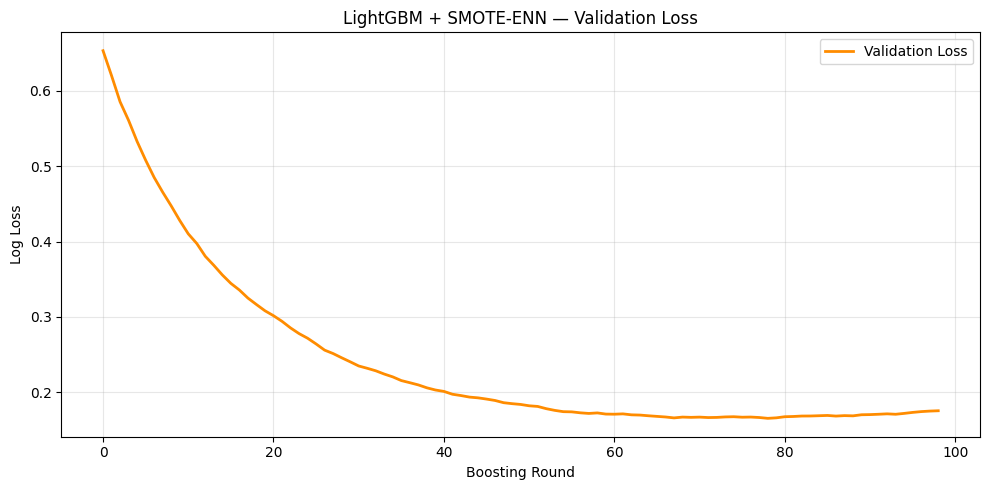

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lgb_history["val_loss"], label="Validation Loss", linewidth=2, color="darkorange")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("Log Loss")
ax.set_title("LightGBM + SMOTE-ENN — Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / "lgb_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Evaluation

Evaluate on the held-out **10% test set** using full M0–M12 data, with **optimized classification threshold** from validation set.

In [8]:
def predict_at_month(model, X_temporal_subset, X_static_subset,
                     up_to_month, temporal_names, static_names,
                     n_features_full):
    """
    Generate predictions using data up to a specific month.
    Pads feature vector to match the full M12 width the model was trained on.
    """
    X_month, _ = build_features_at_month(
        X_temporal_subset, X_static_subset,
        up_to_month=up_to_month,
        temporal_names=temporal_names,
        static_names=static_names,
    )
    if X_month.shape[1] < n_features_full:
        pad_width = n_features_full - X_month.shape[1]
        X_month = np.hstack([X_month, np.zeros((X_month.shape[0], pad_width),
                                                dtype=np.float32)])
    probs = model.predict_proba(X_month)[:, 1]
    return probs


import model_utils as mu
shared_find_optimal_threshold = mu.find_optimal_threshold


def find_optimal_threshold(model, X_temporal, X_static, y, val_idx,
                           temporal_names, static_names, n_features_full):
    """
    Find the optimal classification threshold on the validation set.
    Uses the shared helper and prioritizes specificity to reduce false positives.
    """
    probs = predict_at_month(
        model, X_temporal[val_idx], X_static[val_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )
    labels = y[val_idx]

    threshold_search = shared_find_optimal_threshold(
        labels,
        probs,
        objective="accuracy",
        min_precision=0.0,
    )

    print("Threshold search objective: accuracy")
    print(f"Threshold search best score: {threshold_search['best_score']:.4f}")
    print(
        f"Threshold search metrics: "
        f"F1={threshold_search['best_metrics']['f1']:.4f}, "
        f"Recall={threshold_search['best_metrics']['recall']:.4f}, "
        f"Specificity={threshold_search['best_metrics']['specificity']:.4f}"
    )
    return threshold_search["best_threshold"]



def evaluate_model(model, X_temporal, X_static, y, test_idx,
                   temporal_names, static_names, n_features_full,
                   threshold=0.5):
    """Full evaluation on held-out test set using M12 data."""
    probs = predict_at_month(
        model, X_temporal[test_idx], X_static[test_idx],
        up_to_month=12,
        temporal_names=temporal_names,
        static_names=static_names,
        n_features_full=n_features_full,
    )
    labels = y[test_idx]
    preds = (probs >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "specificity": recall_score(labels, preds, pos_label=0, zero_division=0),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(labels, probs)
    except ValueError:
        metrics["roc_auc"] = float("nan")
    try:
        metrics["pr_auc"] = average_precision_score(labels, probs)
    except ValueError:
        metrics["pr_auc"] = float("nan")

    cm = confusion_matrix(labels, preds)
    return probs, preds, labels, metrics, cm



def evaluate_per_month(model, X_temporal_subset, X_static_subset,
                       y_subset, temporal_names, static_names,
                       n_features_full, threshold=0.5):
    """Evaluate model accuracy at each month (M0–M12) for test patients."""
    month_metrics = []
    for month in range(13):
        probs = predict_at_month(
            model, X_temporal_subset, X_static_subset,
            up_to_month=month,
            temporal_names=temporal_names,
            static_names=static_names,
            n_features_full=n_features_full,
        )
        preds = (probs >= threshold).astype(int)
        acc = accuracy_score(y_subset, preds)
        f1 = f1_score(y_subset, preds, zero_division=0)
        spec = recall_score(y_subset, preds, pos_label=0, zero_division=0)
        try:
            auc = roc_auc_score(y_subset, probs)
        except ValueError:
            auc = float("nan")

        month_metrics.append({
            "month": f"M{month}", "accuracy": acc,
            "f1": f1, "specificity": spec, "auc": auc,
            "n_correct": int((preds == y_subset).sum()),
            "n_total": len(y_subset),
        })
    return pd.DataFrame(month_metrics)


# ── Feature count at M12 ────────────────────────────────────────
n_features_full = build_features_at_month(
    X_temporal[:1], X_static[:1], 12, temporal_names, static_names
)[0].shape[1]

# ── Evaluate ────────────────────────────────────────────────────
optimal_threshold = find_optimal_threshold(
    lgb_model, X_temporal, X_static, y, val_idx,
    temporal_names, static_names, n_features_full
)
print(f"Optimal threshold: {optimal_threshold:.2f}")

lgb_probs, lgb_preds, lgb_labels, lgb_metrics, lgb_cm = evaluate_model(
    lgb_model, X_temporal, X_static, y, test_idx,
    temporal_names, static_names, n_features_full,
    threshold=optimal_threshold,
)

print(f"\n{'='*55}")
print(f"  LightGBM + SMOTE-ENN — Test Evaluation")
print(f"{'='*55}")
for k, v in lgb_metrics.items():
    print(f"  {k:<14s} : {v:.4f}")
print(f"\nConfusion Matrix:\n{lgb_cm}")
print(f"\n{classification_report(lgb_labels, lgb_preds, target_names=['Failure', 'Success'], zero_division=0)}")

Threshold search objective: accuracy
Threshold search best score: 0.9535
Threshold search metrics: F1=0.9730, Recall=0.9863, Specificity=0.7692
Optimal threshold: 0.22

  LightGBM + SMOTE-ENN — Test Evaluation
  accuracy       : 0.9773
  precision      : 0.9744
  recall         : 1.0000
  f1             : 0.9870
  specificity    : 0.8333
  roc_auc        : 1.0000
  pr_auc         : 1.0000

Confusion Matrix:
[[ 5  1]
 [ 0 38]]

              precision    recall  f1-score   support

     Failure       1.00      0.83      0.91         6
     Success       0.97      1.00      0.99        38

    accuracy                           0.98        44
   macro avg       0.99      0.92      0.95        44
weighted avg       0.98      0.98      0.98        44



### Evaluation Plots

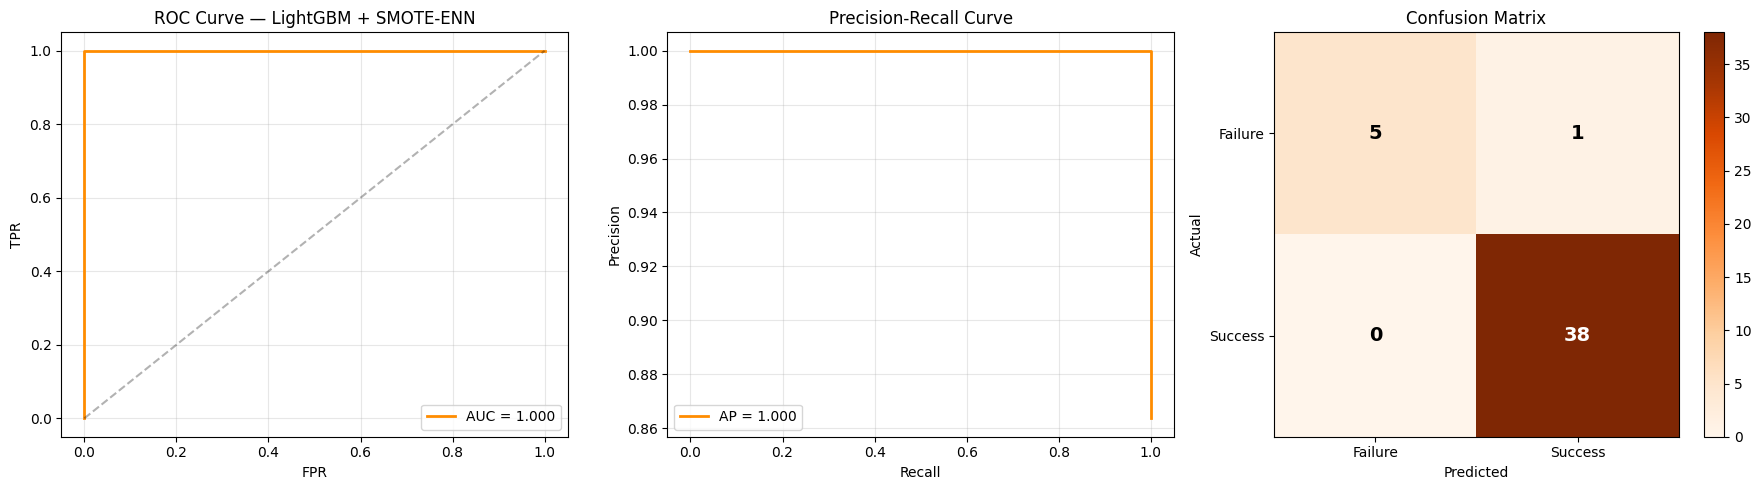

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
try:
    fpr, tpr, _ = roc_curve(lgb_labels, lgb_probs)
    auc_val = roc_auc_score(lgb_labels, lgb_probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}", color="darkorange")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
except ValueError:
    axes[0].text(0.5, 0.5, "Insufficient data", ha="center", va="center")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve — LightGBM + SMOTE-ENN")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR Curve
try:
    prec, rec, _ = precision_recall_curve(lgb_labels, lgb_probs)
    ap = average_precision_score(lgb_labels, lgb_probs)
    axes[1].plot(rec, prec, linewidth=2, label=f"AP = {ap:.3f}", color="darkorange")
except ValueError:
    axes[1].text(0.5, 0.5, "Insufficient data", ha="center", va="center")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion Matrix
im = axes[2].imshow(lgb_cm, cmap="Oranges", interpolation="nearest")
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Failure", "Success"])
axes[2].set_yticklabels(["Failure", "Success"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(lgb_cm[i][j]),
                     ha="center", va="center",
                     color="white" if lgb_cm[i][j] > lgb_cm.max() / 2 else "black",
                     fontsize=14, fontweight="bold")
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig(MODEL_DIR / "lgb_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Importance

LightGBM provides **split-count based** feature importance — how many times each feature was used across all trees.

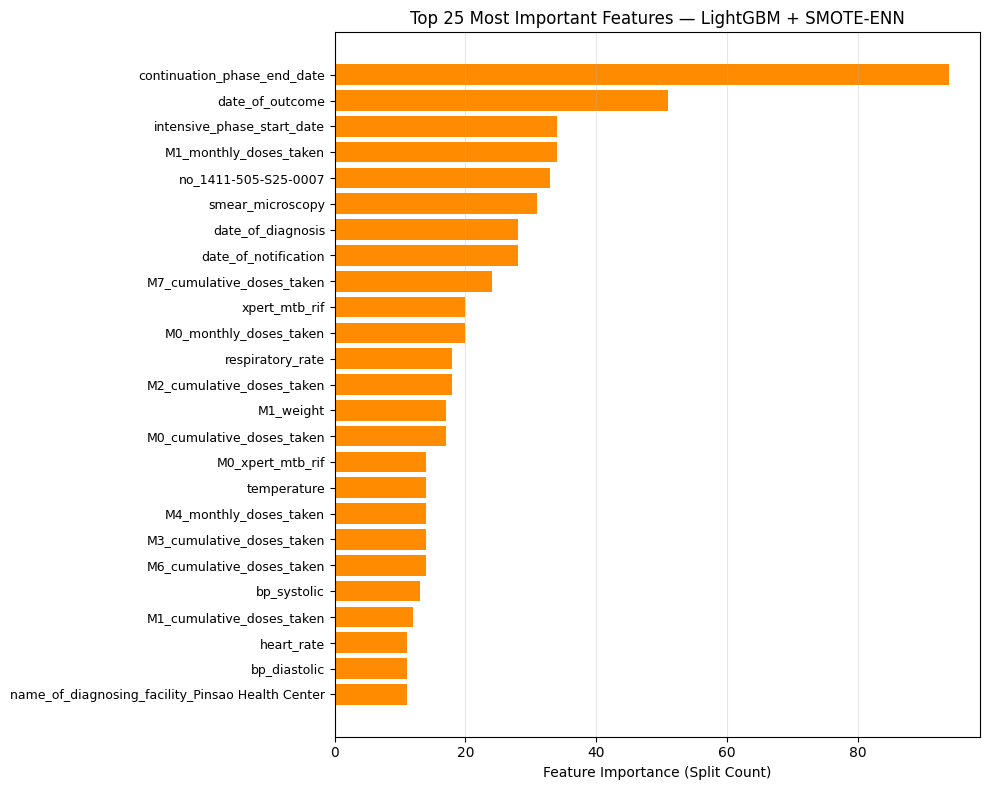


Feature importance by category:
  Static (baseline)             : 539 (59.3%)
  Temporal (raw monthly)        : 370 (40.7%)
  Aggregate (mean/std/min/max)  : 0 (0.0%)
  Trend (slopes)                : 0 (0.0%)
  Latest month                  : 0 (0.0%)


In [10]:
# Get feature importance
importances = lgb_model.feature_importances_

if len(feature_names_lgb) < len(importances):
    feature_names_padded = feature_names_lgb + [
        f"pad_{i}" for i in range(len(importances) - len(feature_names_lgb))
    ]
else:
    feature_names_padded = feature_names_lgb[:len(importances)]

importance_df = pd.DataFrame({
    "feature": feature_names_padded,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 25
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(top_n), top_features["importance"].values[::-1], color="darkorange")
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features["feature"].values[::-1], fontsize=9)
ax.set_xlabel("Feature Importance (Split Count)")
ax.set_title(f"Top {top_n} Most Important Features — LightGBM + SMOTE-ENN")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(MODEL_DIR / "lgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Categorize feature importance
print("\nFeature importance by category:")
categories = {
    "Static (baseline)": [f for f in importance_df["feature"] if not any(
        f.startswith(p) for p in ["M", "mean_", "std_", "min_", "max_",
                                   "trend_", "latest_", "months_"])],
    "Temporal (raw monthly)": [f for f in importance_df["feature"] if f[:1] == "M" and "_" in f],
    "Aggregate (mean/std/min/max)": [f for f in importance_df["feature"]
                                       if any(f.startswith(p) for p in ["mean_", "std_", "min_", "max_"])],
    "Trend (slopes)": [f for f in importance_df["feature"] if f.startswith("trend_")],
    "Latest month": [f for f in importance_df["feature"] if f.startswith("latest_")],
}

for cat_name, cat_features in categories.items():
    cat_importance = importance_df[importance_df["feature"].isin(cat_features)]["importance"].sum()
    print(f"  {cat_name:<30s}: {cat_importance} "
          f"({cat_importance / importances.sum() * 100:.1f}%)")

## 7. Per-Month Prediction Accuracy

Evaluate prediction quality at each month M0–M12 across all test patients.

Per-month — LightGBM + SMOTE-ENN (threshold=0.22):
month  accuracy       f1  specificity      auc  n_correct  n_total
   M0  0.909091 0.950000     0.333333 0.956140         40       44
   M1  0.954545 0.974359     0.666667 0.973684         42       44
   M2  0.977273 0.987013     0.833333 0.978070         43       44
   M3  0.977273 0.987013     0.833333 0.973684         43       44
   M4  0.954545 0.974359     0.666667 0.973684         42       44
   M5  0.977273 0.987013     0.833333 0.982456         43       44
   M6  0.977273 0.987013     0.833333 0.982456         43       44
   M7  0.977273 0.987013     0.833333 1.000000         43       44
   M8  0.977273 0.987013     0.833333 1.000000         43       44
   M9  0.977273 0.987013     0.833333 1.000000         43       44
  M10  0.977273 0.987013     0.833333 1.000000         43       44
  M11  0.977273 0.987013     0.833333 1.000000         43       44
  M12  0.977273 0.987013     0.833333 1.000000         43       44


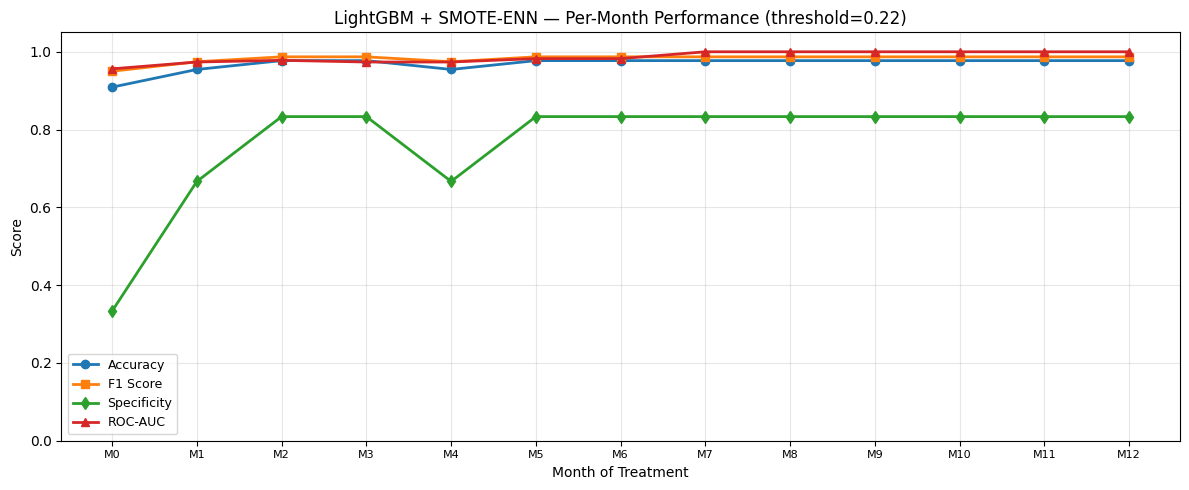

In [11]:
test_temporal = X_temporal[test_idx]
test_static = X_static[test_idx]
test_labels = y[test_idx]

lgb_monthly = evaluate_per_month(
    lgb_model, test_temporal, test_static, test_labels,
    temporal_names, static_names, n_features_full,
    threshold=optimal_threshold,
)

print(f"Per-month — LightGBM + SMOTE-ENN (threshold={optimal_threshold:.2f}):")
print(lgb_monthly.to_string(index=False))

# Plot per-month performance
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(13), lgb_monthly["accuracy"], "o-", label="Accuracy", linewidth=2)
ax.plot(range(13), lgb_monthly["f1"], "s-", label="F1 Score", linewidth=2)
ax.plot(range(13), lgb_monthly["specificity"], "d-", label="Specificity", linewidth=2)
ax.plot(range(13), lgb_monthly["auc"], "^-", label="ROC-AUC", linewidth=2)
ax.set_xlabel("Month of Treatment")
ax.set_ylabel("Score")
ax.set_title(f"LightGBM + SMOTE-ENN — Per-Month Performance (threshold={optimal_threshold:.2f})")
ax.set_xticks(range(13))
ax.set_xticklabels([f"M{i}" for i in range(13)], fontsize=8)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(MODEL_DIR / "lgb_per_month_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Cross-Validation (Robustness Check)

Stratified 5-fold cross-validation provides a more robust estimate of model performance with only 205 patients.

In [12]:
# Build full M12 features for all patients
X_all_full, _ = build_features_at_month(
    X_temporal, X_static, up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)

cv_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=5,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=SEED,
    verbosity=-1,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring_metrics = ["accuracy", "f1", "roc_auc", "precision", "recall"]
print("5-Fold Stratified Cross-Validation Results (M12 features):")
print("-" * 55)

cv_results = {}
for metric in scoring_metrics:
    scores = cross_val_score(cv_model, X_all_full, y, cv=cv, scoring=metric)
    cv_results[metric] = scores
    print(f"  {metric:<12s}: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"(folds: {', '.join(f'{s:.3f}' for s in scores)})")

5-Fold Stratified Cross-Validation Results (M12 features):
-------------------------------------------------------
  accuracy    : 0.9420 ± 0.0283  (folds: 0.920, 0.907, 0.953, 0.988, 0.942)
  f1          : 0.9664 ± 0.0162  (folds: 0.954, 0.947, 0.973, 0.993, 0.966)
  roc_auc     : 0.9453 ± 0.0491  (folds: 0.897, 0.876, 0.980, 0.999, 0.975)
  precision   : 0.9603 ± 0.0231  (folds: 0.935, 0.934, 0.986, 0.986, 0.959)
  recall      : 0.9729 ± 0.0148  (folds: 0.973, 0.959, 0.959, 1.000, 0.973)


## 8. Export to ONNX and ORT

Export the trained LightGBM model to ONNX and ORT formats for web browser deployment.


In [13]:
# Reload model_utils to get the updated export function
import importlib
import sys
if 'model_utils' in sys.modules:
    del sys.modules['model_utils']

from model_utils import export_tree_model_to_onnx

# Prepare dummy sample for ONNX validation
X_dummy, _ = build_features_at_month(
    X_temporal[:1], X_static[:1], up_to_month=12,
    temporal_names=temporal_names, static_names=static_names
)

# Export to ONNX and ORT
print(f"\n{'='*55}")
print(f"  Exporting LightGBM Model to ONNX/ORT")
print(f"{'='*55}")

export_result = export_tree_model_to_onnx(
    fitted_pipeline=lgb_model,
    feature_names=feature_names_lgb,
    model_name="lightgbm_temporal",
    output_dir=MODEL_DIR,
    X_dummy_sample=X_dummy,
)

if export_result['onnx_path']:
    print(f"✓ ONNX: {export_result['onnx_path']}")
    print(f"✓ ORT:  {export_result['ort_path']}")
    print(f"✓ Features: {len(export_result['feature_names'])} dimensions")
    
    # Quick verification: load ONNX and test inference
    import onnxruntime as ort
    
    # Use ONNX file directly (ORT file might have format differences)
    onnx_model_path = export_result['onnx_path']
    try:
        ort_session = ort.InferenceSession(
            str(onnx_model_path),
            providers=['CPUExecutionProvider']
        )
        
        # Test with dummy batch
        X_test_batch = X_dummy[:5].astype(np.float32)
        input_name = ort_session.get_inputs()[0].name
        ort_inputs = {input_name: X_test_batch}
        ort_outputs = ort_session.run(None, ort_inputs)
        ort_probs = ort_outputs[0]
        
        print(f"\n✓ ONNX Inference Verification:")
        print(f"  Input shape:  {X_test_batch.shape}")
        print(f"  Output shape: {ort_probs.shape}")
        print(f"  Sample predictions: {ort_probs[:3].flatten()}")
        print(f"  Output range: [{ort_probs.min():.4f}, {ort_probs.max():.4f}]")
        print(f"\n✓ Model is ready for web deployment")
        print(f"  Use .onnx file with ONNX Runtime in browser or Node.js")
    except Exception as e:
        print(f"\n⚠ Inference test failed: {type(e).__name__}: {str(e)[:100]}")
        print(f"  ONNX file is still valid, may be format/provider issue")
else:
    print(f"✗ ONNX export failed")
    if 'checkpoint_path' in export_result and export_result['checkpoint_path']:
        print(f"✓ Model checkpoint available: {export_result['checkpoint_path']}")
        print(f"  Use: model = joblib.load('{export_result['checkpoint_path']}')")
        print(f"  Then: probs = model.predict_proba(X)")


  Exporting LightGBM Model to ONNX/ORT
Converting lightgbm_temporal to ONNX (detected: LGBMClassifier from lightgbm.sklearn)...
  Using onnxmltools for LightGBM conversion...
✓ ONNX model saved: lightgbm_temporal.onnx
Verifying ONNX model...
✓ ONNX model verified (output shape: (1,))
✓ ORT model saved: lightgbm_temporal.ort
✓ ONNX: c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\lightgbm\lightgbm_temporal.onnx
✓ ORT:  c:\Users\Ven\Documents\Thesis\TB-DOTS-CAR-CDSS\models\Temporal\v2\output\lightgbm\lightgbm_temporal.ort
✓ Features: 723 dimensions

✓ ONNX Inference Verification:
  Input shape:  (1, 723)
  Output shape: (1,)
  Sample predictions: [1]
  Output range: [1.0000, 1.0000]

✓ Model is ready for web deployment
  Use .onnx file with ONNX Runtime in browser or Node.js


## 9. Save Model Config & Evaluation Report

In [14]:
# ── Save model config ────────────────────────────────────────────
config = {
    "model": "LightGBM + SMOTE-ENN",
    "augmentation": "SMOTE-ENN (Synthetic Minority Oversampling + Edited Nearest Neighbors)",
    "lightgbm_params": {
        "n_estimators": 300, "max_depth": 4, "learning_rate": 0.05,
        "num_leaves": 31, "min_child_samples": 5,
        "is_unbalance": True,
    },
    "n_features": int(n_features_full),
    "n_patients": int(len(y)),
    "train_patients": int(len(train_idx)),
    "val_patients": int(len(val_idx)),
    "test_patients": int(len(test_idx)),
    "training_mode": "progressive_temporal (one sample per patient per month, M0-M12)",
    "split": "70/20/10 (patient-level, stratified)",
    "seed": SEED,
    "threshold": float(optimal_threshold),
    "best_iteration": int(lgb_model.best_iteration_),
}
with open(MODEL_DIR / "lgb_model_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("✓ models/lgb_model_config.json")

# ── Save evaluation report ──────────────────────────────────────
report_lines = [
    "TB-DOTS CAR CDSS — LightGBM Evaluation Report",
    "=" * 60,
    f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"Dataset: {len(y)} patients, split 70/20/10 (patient-level, stratified)",
    f"Training mode: Progressive temporal — 13 samples/patient (M0..M12)",
    f"Features: {n_features_full} (static + engineered temporal)",
    f"Augmentation: SMOTE-ENN",
    f"Optimal threshold: {optimal_threshold:.2f}",
    f"Best iteration: {lgb_model.best_iteration_}",
    "",
    f"{'='*55}",
    f"  Test Set Evaluation",
    f"{'='*55}",
]
for k, v in lgb_metrics.items():
    report_lines.append(f"  {k:<14s} : {v:.4f}")
report_lines.extend([
    "",
    "Confusion Matrix:",
    str(lgb_cm),
    "",
    "Per-Month Performance:",
    "-" * 40,
    lgb_monthly.to_string(index=False),
    "",
    "5-Fold Cross-Validation:",
    "-" * 40,
])
for metric, scores in cv_results.items():
    report_lines.append(f"  {metric:<12s}: {scores.mean():.4f} ± {scores.std():.4f}")

with open(MODEL_DIR / "lgb_evaluation_report.txt", "w") as f:
    f.write("\n".join(report_lines))
print("✓ models/lgb_evaluation_report.txt")

# ── Save metrics JSON for cross-notebook comparison ─────────────
lgb_metrics_export = {k: float(v) for k, v in lgb_metrics.items()}
lgb_metrics_export["threshold"] = float(optimal_threshold)
lgb_metrics_export["best_iteration"] = int(lgb_model.best_iteration_)
with open(MODEL_DIR / "lgb_metrics.json", "w") as f:
    json.dump(lgb_metrics_export, f, indent=2)
print("✓ models/lgb_metrics.json")

print("\nAll saved files:")
print("  ✓ models/lgb_smoteenn_model.txt")
print("  ✓ models/lgb_model_config.json")
print("  ✓ models/lgb_evaluation_report.txt")
print("  ✓ models/lgb_metrics.json")
print("  ✓ models/lgb_evaluation_plots.png")
print("  ✓ models/lgb_feature_importance.png")
print("  ✓ models/lgb_per_month_performance.png")
print("  ✓ models/lgb_training_curve.png")

✓ models/lgb_model_config.json
✓ models/lgb_evaluation_report.txt
✓ models/lgb_metrics.json

All saved files:
  ✓ models/lgb_smoteenn_model.txt
  ✓ models/lgb_model_config.json
  ✓ models/lgb_evaluation_report.txt
  ✓ models/lgb_metrics.json
  ✓ models/lgb_evaluation_plots.png
  ✓ models/lgb_feature_importance.png
  ✓ models/lgb_per_month_performance.png
  ✓ models/lgb_training_curve.png
